# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> ONNX -> TfLite

In [1]:
import os
import torch

from model_compression.src.utils import load_data, process_callbacks
from model_compression.src.converters.to_onnx import export_pytorch_to_onnx, export_onnx_to_savedmodel, export_savedmodel_to_tflite
from model_compression.src.train.knowledge_distillation import train_kd
from model_compression.src.utils.logging_setup import configure_logging

2025-05-01 18:34:47.477161: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 18:34:47.485494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746138887.494524   19050 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746138887.497244   19050 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746138887.505245   19050 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-05-01 18:34:49,795 preprocessing.py:44] Train size: 29322
[INFO 2025-05-01 18:34:49,795 preprocessing.py:47]   Class 'Actinic keratoses': 693 samples
[INFO 2025-05-01 18:34:49,795 preprocessing.py:47]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-05-01 18:34:49,795 preprocessing.py:47]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-05-01 18:34:49,795 preprocessing.py:47]   Class 'Chickenpox': 900 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'Cowpox': 792 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'Dermatofibroma': 191 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'HFMD': 1932 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'Healthy': 1368 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'Measles': 660 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.py:47]   Class 'Melanocytic nevi': 10300 samples
[INFO 2025-05-01 18:34:49,796 preprocessing.p

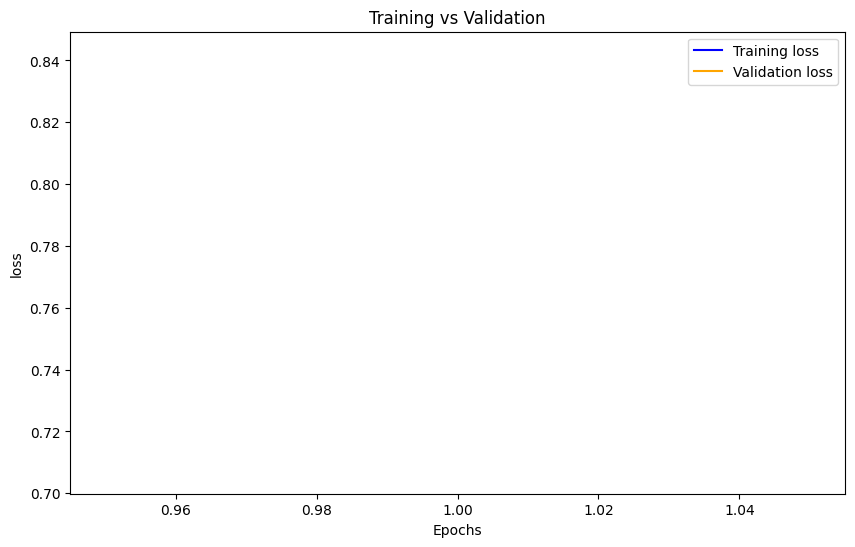

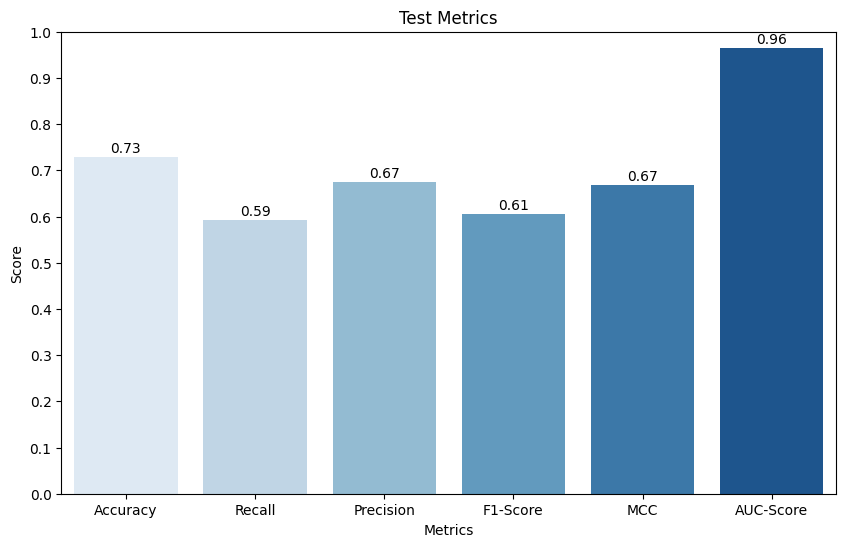

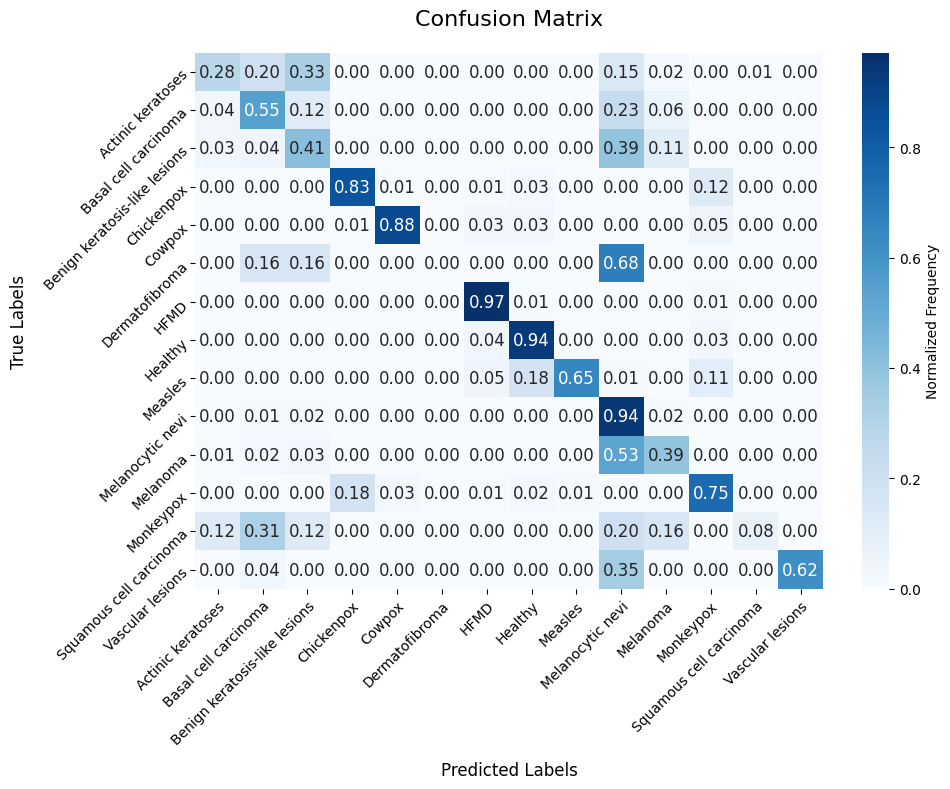

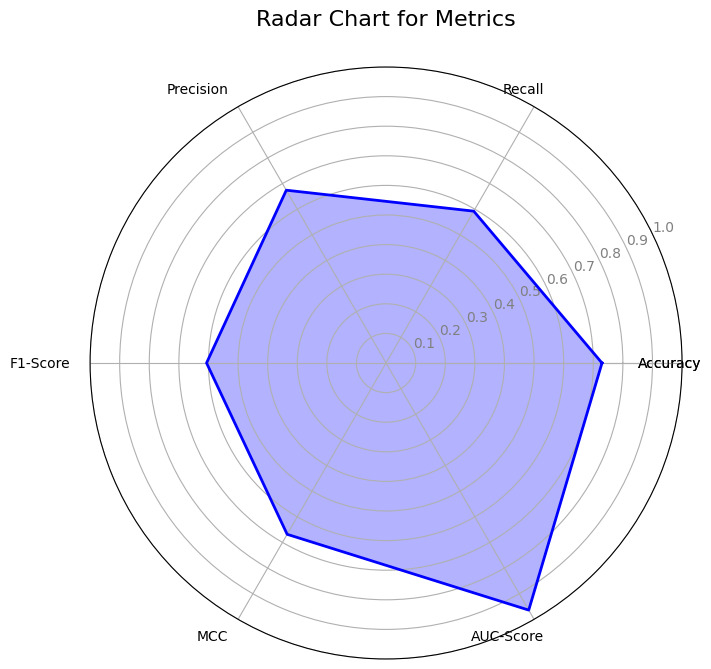

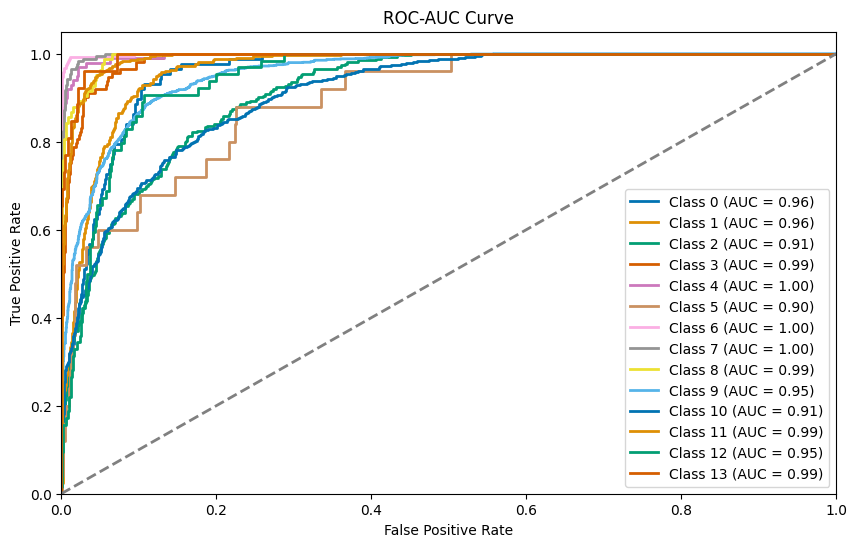

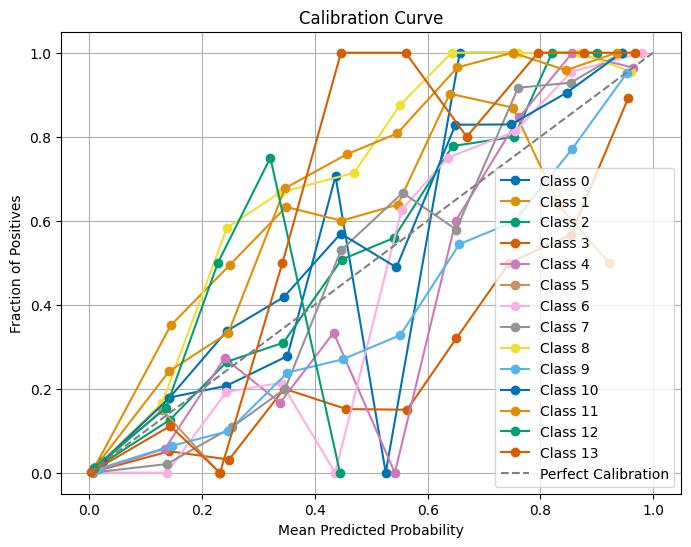

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset_name=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        num_epochs=epochs,
                                        criterion_name = criterion,
                                        optimizer_name = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_weights_path=teacher_model_weights,
                                        device=device,
                                )


### 2. Export to ONNX

In [5]:
example_inputs = next(iter(dataloaders['train']))[0]
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_pytorch_to_onnx(quantized_student.to("cpu"), example_inputs.to("cpu"), onnx_path, dynamo=True, opset_version=12)

[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[ERROR 2025-05-01 18:41:12,172 to_onnx.py:80] ONNX export failed: Failed to decompose the FX graph for ONNX compatibility. This is step 2/3 of exporting the model to ONNX. Next steps:
- Create an issue in the PyTorch GitHub repository against the *torch.export* component and attach the full error stack as well as reproduction scripts.
- Create an error report with `torch.onnx.export(..., report=True)`, and save the ExportedProgram as a pt2 file. Create an issue in the PyTorch GitHub repository against the *onnx* component. Attach the error report and the pt2 model.

## Exception summary

<class 'RuntimeError'>:         Encountered duplicated inputs that are mutated in the graph you are trying to export.
        This functionality is currently not supported. If needed, please file a github issue.

        fw_metadata=ViewAndMutationMeta(input_info=[InputAliasInfo(is_leaf=True, mutates_data=False, mutates_metadata=False, mutations_hidden_from_autograd=True, mutations_under_no_grad_or_inf

[torch.onnx] Run decomposition... ❌


RuntimeError: Failed to export to ONNX: Failed to decompose the FX graph for ONNX compatibility. [96mThis is step 2/3[0m of exporting the model to ONNX. Next steps:
- Create an issue in the PyTorch GitHub repository against the [96m*torch.export*[0m component and attach the full error stack as well as reproduction scripts.
- Create an error report with `torch.onnx.export(..., report=True)`, and save the ExportedProgram as a pt2 file. Create an issue in the PyTorch GitHub repository against the [96m*onnx*[0m component. Attach the error report and the pt2 model.

## Exception summary

<class 'RuntimeError'>:         Encountered duplicated inputs that are mutated in the graph you are trying to export.
        This functionality is currently not supported. If needed, please file a github issue.

        fw_metadata=ViewAndMutationMeta(input_info=[InputAliasInfo(is_leaf=True, mutates_data=False, mutates_metadata=False, mutations_hidden_from_autograd=True, mutations_under_no_grad_or_in

### 3. Convert ONNX → TensorFlow SavedModel

In [ ]:
save_dir = f"models/{dataset}/Quantized"
student_model = "mobilenet_v2"
dataloaders = load_data(dataset=dataset, batch_size=batch_size)

[INFO 2025-04-24 18:39:11,820 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-24 18:39:11,821 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-24 18:39:11,821 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-24 18:39:11,823 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-24 18:39:11,823 preprocessi

In [ ]:
tf_saved_model_dir = os.path.join(save_dir, f"{student_model}_qat_kd")
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_onnx_to_savedmodel(onnx_path, tf_saved_model_dir)

2025-04-23 21:05:10.384672: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-23 21:05:10.384872: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-23 21:05:10.385668: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required l

StagingError: in user code:

    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/backend_tf_module.py", line 99, in __call__  *
        output_ops = self.backend._onnx_node_to_tensorflow_op(onnx_node,
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/backend.py", line 347, in _onnx_node_to_tensorflow_op  *
        return handler.handle(node, tensor_dict=tensor_dict, strict=strict)
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/handlers/handler.py", line 59, in handle  *
        return ver_handle(node, **kwargs)
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/handlers/backend/squeeze.py", line 34, in version_13  *
        axes = kwargs["tensor_dict"][node.inputs[1]]

    IndexError: list index out of range


### 4. Convert SavedModel → TFLite

In [ ]:
tflite_path = os.path.join(save_dir, f"{student_model}_qat_kd.tflite")
export_savedmodel_to_tflite(tf_saved_model_dir, tflite_path, dataloaders["train"])

### 5. Model sizes

In [ ]:
print(os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)

In [ ]:
# TODO: Try a different model from mobilenetv2
# TODO: Get weights from QAT and then use post-training quantization
# TODO: explore more optimization techniques (low-rank aproximation)
print(os.path.getsize("models/SkinCancer/Quantized/quantized_student_state.pth") / 1e6)